In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# STEP 1: Load Dataset

df = pd.read_csv("weather_dataset_500.csv")

print("Dataset Loaded Successfully")




Dataset Loaded Successfully


In [ ]:

print("\nFirst 5 Records:\n", df.head())



First 5 Records:
     City  Year Month  Temperature  Rainfall  Humidity  WindSpeed
0  Delhi  2010   Jan           19        42        38          5
1  Delhi  2010   Feb           20        44        41          6
2  Delhi  2010   Mar           21        46        44          7
3  Delhi  2010   Apr           22        48        47          8
4  Delhi  2010   May           23        50        50          9


In [ ]:
print("Shape of Dataset:", df.shape)
df.head()

Shape of Dataset: (500, 7)


,City,Year,Month,Temperature,Rainfall,Humidity,WindSpeed
0,Delhi,2010,Jan,19,42,38,5
1,Delhi,2010,Feb,20,44,41,6
2,Delhi,2010,Mar,21,46,44,7
3,Delhi,2010,Apr,22,48,47,8
4,Delhi,2010,May,23,50,50,9


In [ ]:
df=df.convert_dtypes()
df.head()

,City,Year,Month,Temperature,Rainfall,Humidity,WindSpeed
0,Delhi,2010,Jan,19,42,38,5
1,Delhi,2010,Feb,20,44,41,6
2,Delhi,2010,Mar,21,46,44,7
3,Delhi,2010,Apr,22,48,47,8
4,Delhi,2010,May,23,50,50,9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   City         500 non-null    string
 1   Year         500 non-null    Int64 
 2   Month        500 non-null    string
 3   Temperature  500 non-null    Int64 
 4   Rainfall     500 non-null    Int64 
 5   Humidity     500 non-null    Int64 
 6   WindSpeed    500 non-null    Int64 
dtypes: Int64(5), string(2)
memory usage: 29.9 KB


In [ ]:
df.describe()

,Year,Temperature,Rainfall,Humidity,WindSpeed
count,500.0,500.0,500.0,500.0,500.0
mean,2014.336,26.564,59.336,54.404,9.484
std,2.931261,4.04557,8.333186,10.347508,3.442302
min,2010.0,18.0,42.0,38.0,4.0
25%,2012.0,23.0,54.0,44.0,6.75
50%,2014.0,27.0,60.0,53.0,9.0
75%,2017.0,30.0,66.0,62.0,12.0
max,2019.0,37.0,80.0,71.0,15.0


In [ ]:
print(df.isnull().sum())
df.head()

City           0
Year           0
Month          0
Temperature    0
Rainfall       0
Humidity       0
WindSpeed      0
dtype: int64


,City,Year,Month,Temperature,Rainfall,Humidity,WindSpeed
0,Delhi,2010,Jan,19,42,38,5
1,Delhi,2010,Feb,20,44,41,6
2,Delhi,2010,Mar,21,46,44,7
3,Delhi,2010,Apr,22,48,47,8
4,Delhi,2010,May,23,50,50,9


In [ ]:
df.fillna(df.mean(numeric_only=True),inplace=True)
df.isnull().sum()

,0
City,0
Year,0
Month,0
Temperature,0
Rainfall,0
Humidity,0
WindSpeed,0


In [ ]:
df.to_csv('/content/weather_dataset_500.csv',index=False)
print("Cleaned Data Saved Successfully")

Cleaned Data Saved Successfully


In [ ]:
df["Year"]=df["Year"].astype(int)

In [ ]:
# Ensure numeric columns are correct datatype
num_cols = ["Temperature", "Rainfall", "Humidity", "WindSpeed"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")


In [ ]:
df=df.drop_duplicates()
print("\nAfter Removing Duplicates:\n",df.shape)


After Removing Duplicates:
 (500, 7)


In [ ]:
# STEP 3: Search Function

def search_by_year(year):
    result = df[df["Year"] == year]
    if not result.empty:
        print(f"\nSearch Result for Year {year}:")
        print(result.head())   # show first 5 rows
    else:
        print("\nNo records found for that year.")

search_by_year(2016)



Search Result for Year 2016:
     City  Year Month  Temperature  Rainfall  Humidity  WindSpeed
72  Delhi  2016   Jan           25        42        38          5
73  Delhi  2016   Feb           26        44        41          6
74  Delhi  2016   Mar           27        46        44          7
75  Delhi  2016   Apr           28        48        47          8
76  Delhi  2016   May           29        50        50          9


In [ ]:
# Group by city and year → Avg values
city_year_group = df.groupby(["City", "Year"]).mean(numeric_only=True)
print("\nAverage Weather Data by City-Year:\n", city_year_group.head())



Average Weather Data by City-Year:
                 Temperature  Rainfall  Humidity  WindSpeed
City      Year                                            
Bangalore 2010         24.5      69.0      54.5        9.5
          2011         24.5      65.0      48.5        8.5
Chennai   2010         25.5      61.0      54.5        9.5
          2011         26.5      61.0      54.5        9.5
          2012         27.5      61.0      54.5        9.5


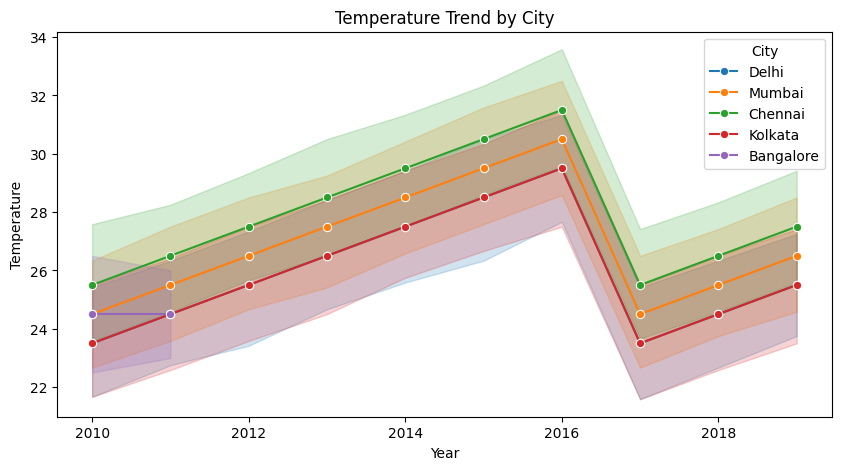

In [ ]:
# 1. Temperature trend
plt.figure(figsize=(10,5))
sns.lineplot(x="Year", y="Temperature", hue="City", data=df, marker="o")
plt.title("Temperature Trend by City")
plt.show()


/tmp/ipython-input-2523277165.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="City", y="Rainfall", ci=None, palette="Set2")
/tmp/ipython-input-2523277165.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="City", y="Rainfall", ci=None, palette="Set2")


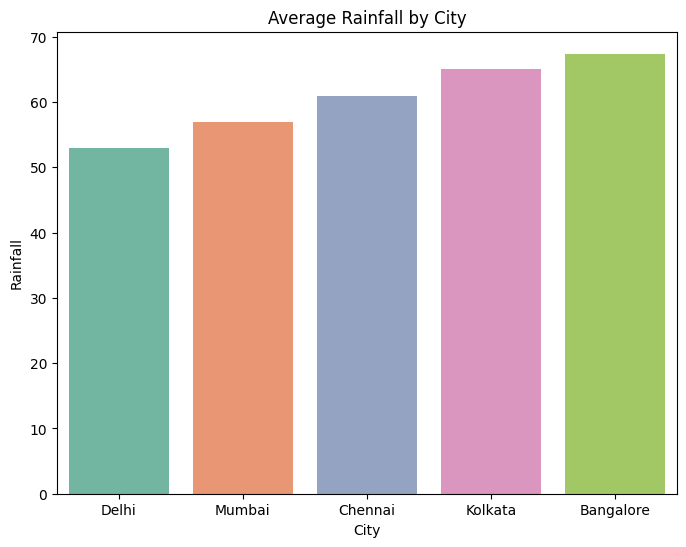

In [ ]:
# Bar Chart – Average Rainfall by City
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="City", y="Rainfall", ci=None, palette="Set2")
plt.title("Average Rainfall by City")
plt.show()


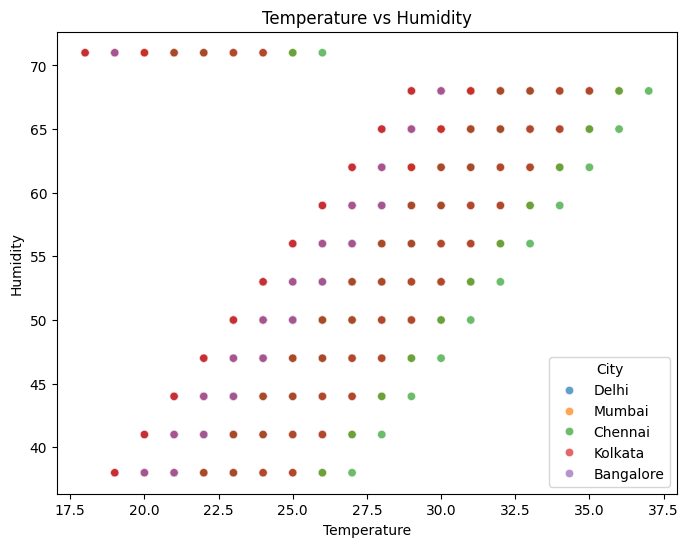

In [ ]:
# Scatter Plot – Temperature vs Humidity
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Temperature", y="Humidity", hue="City", alpha=0.7)
plt.title("Temperature vs Humidity")
plt.show()


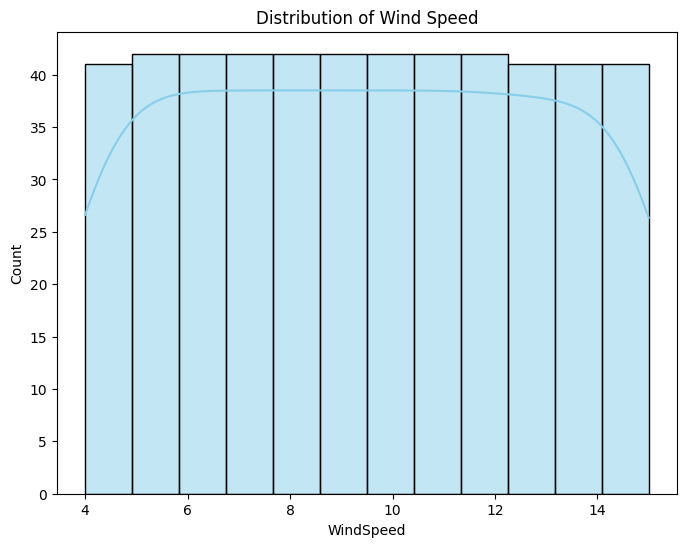

In [ ]:
# Histogram – Wind Speed Distribution
plt.figure(figsize=(8,6))
sns.histplot(df["WindSpeed"], bins=12, kde=True, color="skyblue")
plt.title("Distribution of Wind Speed")
plt.show()


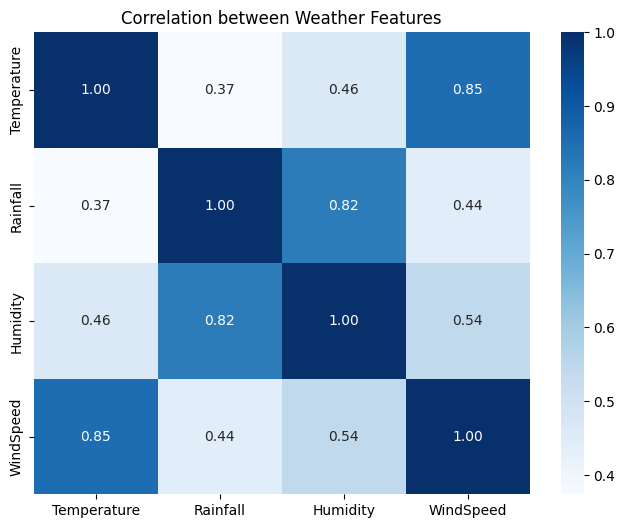

In [ ]:
# 5. Heatmap (Correlation)
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation between Weather Features")
plt.show()


In [ ]:
# STEP 5: Final Summary Report
# ===============================
print("\n--- 🌍 WEATHER SUMMARY REPORT ---")
print("Highest Temperature Recorded:", df["Temperature"].max())
print("Lowest Temperature Recorded:", df["Temperature"].min())
print("Total Rainfall (All Cities):", df["Rainfall"].sum())
print("Average Humidity Overall:", round(df["Humidity"].mean(),2))
print("City with Maximum Average Rainfall:", df.groupby("City")["Rainfall"].mean().idxmax())
print("City with Minimum Average Rainfall:", df.groupby("City")["Rainfall"].mean().idxmin())
print("Year with Highest Avg Temperature:", df.groupby("Year")["Temperature"].mean().idxmax())
print("Year with Lowest Avg Temperature:", df.groupby("Year")["Temperature"].mean().idxmin())


--- 🌍 WEATHER SUMMARY REPORT ---
Highest Temperature Recorded: 37
Lowest Temperature Recorded: 18
Total Rainfall (All Cities): 29668
Average Humidity Overall: 54.4
City with Maximum Average Rainfall: Bangalore
City with Minimum Average Rainfall: Delhi
Year with Highest Avg Temperature: 2016
Year with Lowest Avg Temperature: 2017
